# Forest Patch Prototype

Visualise the patched heightmaps from the validation set: zoomed-in crops showing heightmap vs terrain RGB side by side.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt

from cogniland.env.islands import colorize
from cogniland.env.types import EnvConfig, MapGenConfig
from cogniland.env.dataset import MapDataset

In [2]:
# ── Config & terrain lookup ───────────────────────────────────────────────────
config   = EnvConfig(map_generation=MapGenConfig(seed=42))
compiled = config.compile_terrain('cpu')

thresholds = compiled.thresholds.numpy()
colors     = compiled.color_lut.numpy()
names      = compiled.terrain_names

print(f"Thresholds: {dict(zip(names, thresholds.round(3)))}")


def to_terrain_rgb(hm):
    """Heightmap → RGB via threshold lookup."""
    h = hm.numpy() if isinstance(hm, torch.Tensor) else hm
    idx = np.full(h.shape, len(thresholds) - 1, dtype=np.int8)
    for k in range(len(thresholds) - 1, -1, -1):
        idx[h < thresholds[k]] = k
    return colors[idx].astype(np.uint8)

Thresholds: {'ocean': np.float32(0.007), 'deep_water': np.float32(0.025), 'water': np.float32(0.05), 'beach': np.float32(0.06), 'sandy': np.float32(0.1), 'grassland': np.float32(0.25), 'forest': np.float32(0.6), 'rocky': np.float32(0.7), 'mountains': np.float32(1.0)}


In [3]:
# ── Load validation set (already patched by generate_dataset.py) ─────────────
dataset = MapDataset.from_split_files(
    train_path='../data/train_seed42_n128.pt',
    val_path='../data/val_seed42_n16.pt',
    test_path='../data/test_seed42_n16.pt',
)
print(f"Loaded {dataset.n_val} val maps, shape: {dataset.val_maps.shape}")

Loaded 16 val maps, shape: torch.Size([16, 250, 250])


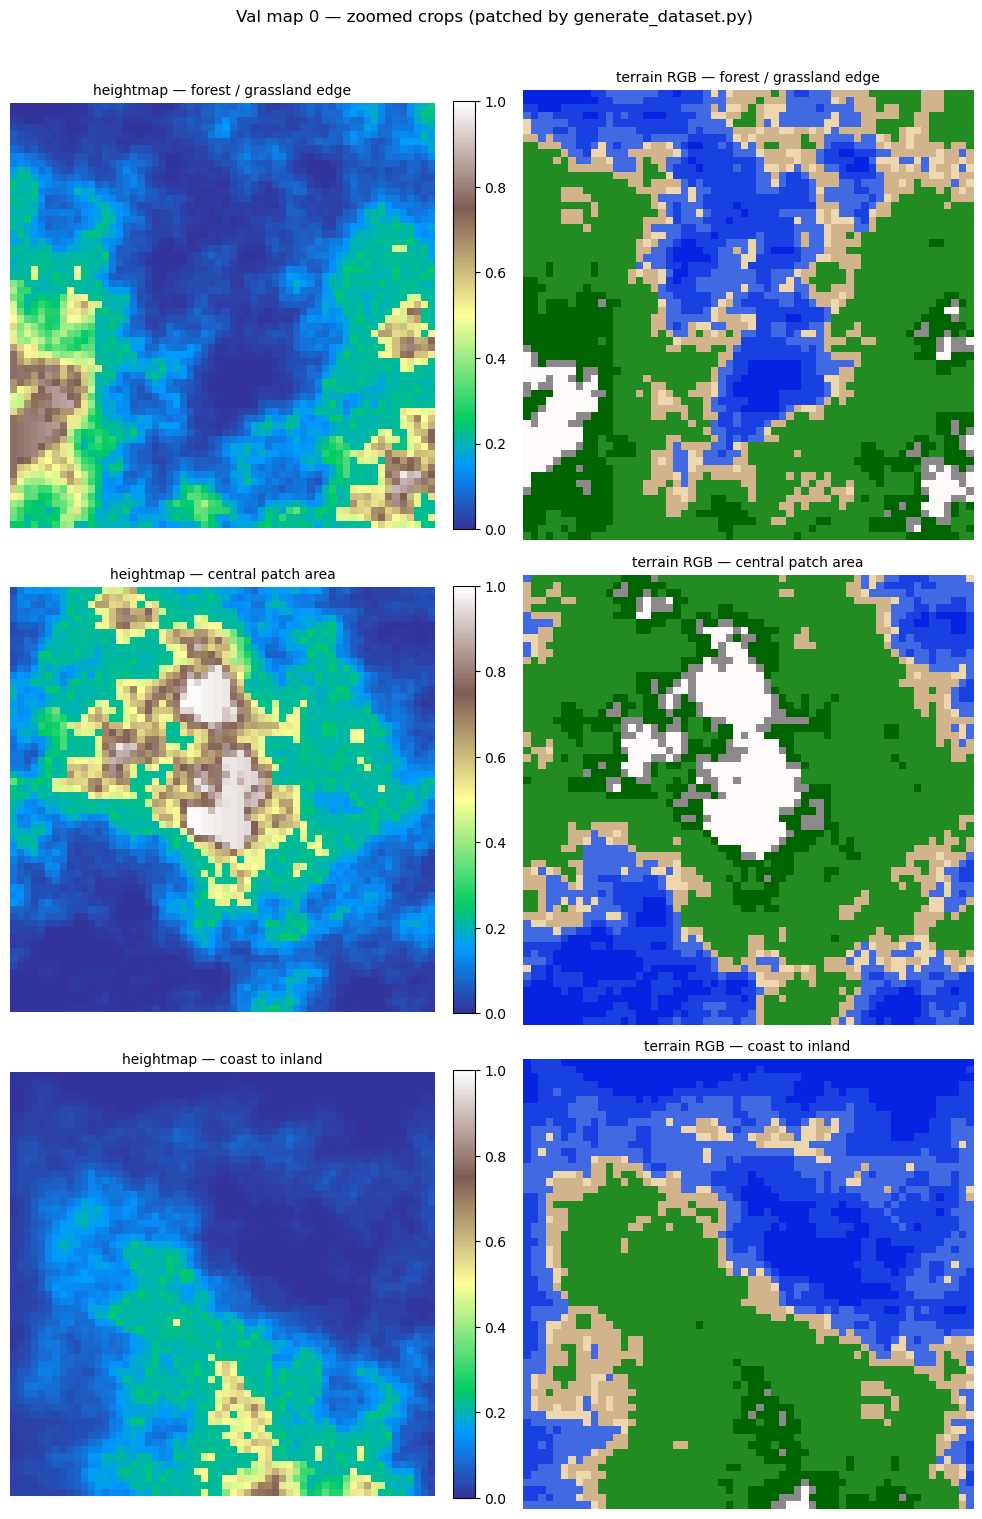

In [4]:
# ── Zoomed-in crops: heightmap vs terrain RGB ────────────────────────────────
# Pick a map and cut 3 interesting regions (forest edges, patches, coastline)
hm = dataset.val_maps[0].numpy()
rgb = to_terrain_rgb(hm)

# Define crop regions [row_start, row_end, col_start, col_end]
crops = [
    (70,  130, 80,  140, 'forest / grassland edge'),
    (100, 160, 120, 180, 'central patch area'),
    (40,  100, 40,  100, 'coast to inland'),
]

fig, axes = plt.subplots(len(crops), 2, figsize=(10, 5 * len(crops)))

for i, (r0, r1, c0, c1, label) in enumerate(crops):
    hm_crop  = hm[r0:r1, c0:c1]
    rgb_crop = rgb[r0:r1, c0:c1]

    # Heightmap
    im = axes[i, 0].imshow(hm_crop, cmap='terrain', vmin=0.0, vmax=1.0, interpolation='nearest')
    axes[i, 0].set_title(f'heightmap — {label}', fontsize=10)
    axes[i, 0].set_ylabel(f'[{r0}:{r1}, {c0}:{c1}]', fontsize=8)
    axes[i, 0].axis('off')
    plt.colorbar(im, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # Terrain RGB
    axes[i, 1].imshow(rgb_crop)
    axes[i, 1].set_title(f'terrain RGB — {label}', fontsize=10)
    axes[i, 1].axis('off')

fig.suptitle(f'Val map 0 — zoomed crops (patched by generate_dataset.py)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()